In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

import joblib

In [3]:
try:
    from xgboost import XGBClassifier
    print("XGBoost is available.")
except ImportError:
    print("XGBoost is not installed.")

XGBoost is available.


In [4]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"

df = pd.read_csv(url)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
target = "survived"

X = df.drop(columns=[target])
y = df[target]

print("Features:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

Features:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Target distribution:
survived
0    549
1    342
Name: count, dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (712, 14)
Testing: (179, 14)


In [7]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical:", numeric_features)
print("Categorical:", categorical_features)

Numerical: ['pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical: ['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


C:\Users\Kabilan\AppData\Local\Temp\ipykernel_6088\339432327.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [8]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

print("Preprocessing pipeline ready.")

Preprocessing pipeline ready.


In [9]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),
    
    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss"
    )
}

print("4 models created:")
for name in models:
    print("-", name)

4 models created:
- Logistic Regression
- Random Forest
- Gradient Boosting
- XGBoost


In [10]:
model_pipelines = {}

for name, model in models.items():
    model_pipelines[name] = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

print("Pipelines created successfully.")

Pipelines created successfully.


In [11]:
for name, pipeline in model_pipelines.items():
    pipeline.fit(X_train, y_train)
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.
XGBoost trained successfully.


In [12]:
results = []

for name, pipeline in model_pipelines.items():
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,1.0,1.0,1.0,1.0,1.0
1,Gradient Boosting,1.0,1.0,1.0,1.0,1.0
2,XGBoost,1.0,1.0,1.0,1.0,1.0
3,Logistic Regression,1.0,1.0,1.0,1.0,1.0


In [13]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-fold Stratified Cross-Validation created.")

5-fold Stratified Cross-Validation created.


In [14]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

logistic_params = {
    "model__C": [0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"]
}

logistic_grid = GridSearchCV(
    logistic_pipeline,
    logistic_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

logistic_grid.fit(X_train, y_train)

print("Best Logistic Regression parameters:")
print(logistic_grid.best_params_)

print("Best CV ROC-AUC:", round(logistic_grid.best_score_, 3))

Best Logistic Regression parameters:
{'model__C': 0.1, 'model__solver': 'liblinear'}
Best CV ROC-AUC: 1.0


In [15]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            random_state=42
        ))
    ]
)

rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(rf_grid.best_params_)

print("Best CV ROC-AUC:", round(rf_grid.best_score_, 3))

Best Random Forest parameters:
{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV ROC-AUC: 1.0


In [16]:
gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(
            random_state=42
        ))
    ]
)

gb_params = {
    "model__n_estimators": [50, 100],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3]
}

gb_grid = GridSearchCV(
    gb_pipeline,
    gb_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("Best Gradient Boosting parameters:")
print(gb_grid.best_params_)
print("Best CV ROC-AUC:", round(gb_grid.best_score_, 3))

Best Gradient Boosting parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 50}
Best CV ROC-AUC: 1.0


In [17]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        ))
    ]
)

xgb_params = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [2, 3],
    "model__learning_rate": [0.05, 0.1]
}

xgb_grid = GridSearchCV(
    xgb_pipeline,
    xgb_params,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best XGBoost parameters:")
print(xgb_grid.best_params_)
print("Best CV ROC-AUC:", round(xgb_grid.best_score_, 3))

Best XGBoost parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 50}
Best CV ROC-AUC: 1.0


In [19]:
tuned_models = {
    "Logistic Regression": logistic_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_,
    "Gradient Boosting": gb_grid.best_estimator_,
    "XGBoost": xgb_grid.best_estimator_
}

tuned_results = []

for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0,1.0
2,Gradient Boosting,1.0,1.0,1.0,1.0,1.0
3,XGBoost,1.0,1.0,1.0,1.0,1.0


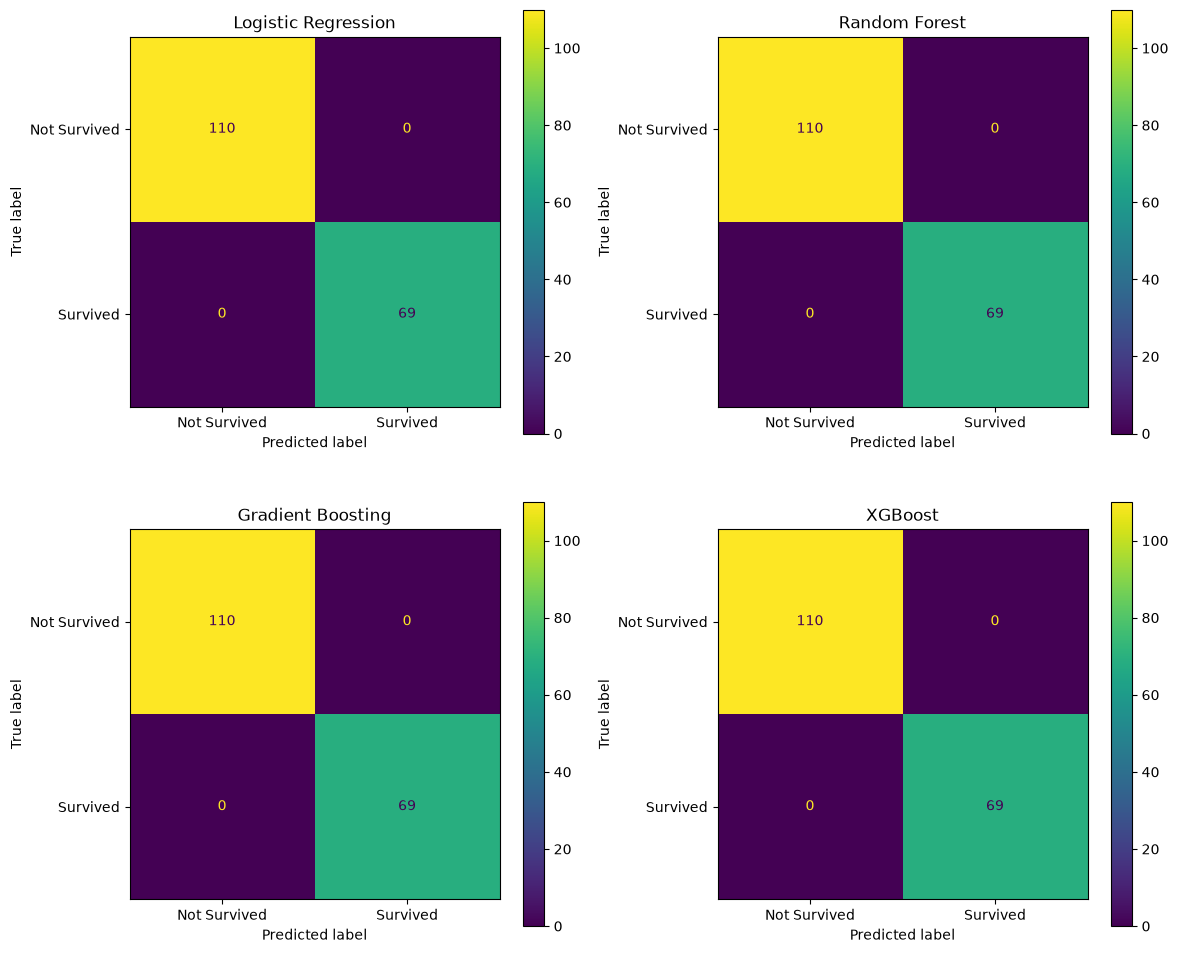

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (name, model) in zip(axes.ravel(), tuned_models.items()):
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Survived", "Survived"]
    ).plot(ax=ax)

    ax.set_title(name)

plt.tight_layout()
plt.show()

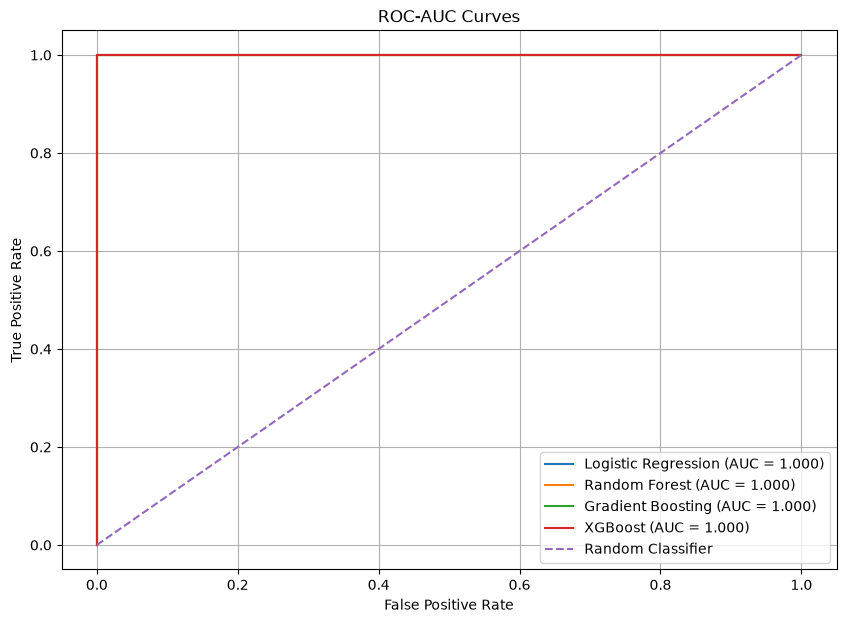

In [21]:
plt.figure(figsize=(10, 7))

for name, model in tuned_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curves")
plt.legend()
plt.grid()
plt.show()

In [22]:
champion_name = tuned_results_df.iloc[0]["Model"]
champion_model = tuned_models[champion_name]

print("Champion Model:", champion_name)
print("\nChampion Metrics:")
print(
    tuned_results_df[
        tuned_results_df["Model"] == champion_name
    ]
)

Champion Model: Logistic Regression

Champion Metrics:
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression       1.0        1.0     1.0       1.0      1.0


In [23]:
joblib.dump(
    champion_model,
    "06_champion_model.joblib"
)

print("Champion model saved successfully.")

Champion model saved successfully.


# Final Summary

## Models Evaluated
Four classification architectures were evaluated:
1. Logistic Regression
2. Random Forest
3. Gradient Boosting
4. XGBoost

## Hyperparameter Optimization
GridSearchCV with Stratified K-Fold cross-validation was used to tune model hyperparameters.

## Evaluation
The models were evaluated using:
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Confusion Matrix
- ROC-AUC curves

## Champion Model
The champion model was selected based on the highest validation/test ROC-AUC shown in the model comparison.

## Serialization
The selected champion model was serialized using Joblib as:
`06_champion_model.joblib`

## Limitation
The Titanic dataset is relatively small for a real production modeling exercise. The results demonstrate the modeling and tuning workflow and should not be treated as evidence of production performance.